In [ ]:
!pip install anndata==0.8.0

In [ ]:
import pandas as pd

In [1]:
from samalg import SAM
import scanpy as sc
import statistics
import matplotlib.pyplot as plt
import seaborn as sns
import random
import pandas as pd
import matplotlib.colors
import scipy
import numpy as np
import sklearn.metrics as metrics
from scipy import sparse
import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
import pickle
from samap.utils import (save_samap, load_samap)
import anndata as ad

In [ ]:
#input: clustered SAM object
#output: seperate h5ads of neurons and nonneurons

In [44]:
sam = SAM()
sam.load_data('../../Active_SAM_joined/SAM_CJ_joined_v2_cleaned_03122025.h5ad')
gene_dict = {}
for i in range(len(sam.adata.var_names)):
    gene_dict[sam.adata.var_names[i]] = i

In [45]:
#input your cell type labels
level = 'ss_subclass_v5_nounlabeled'

In [4]:
#cluster your cell types if you do not already have a label
sam.clustering(param =1)
level = 'leiden_clusters'

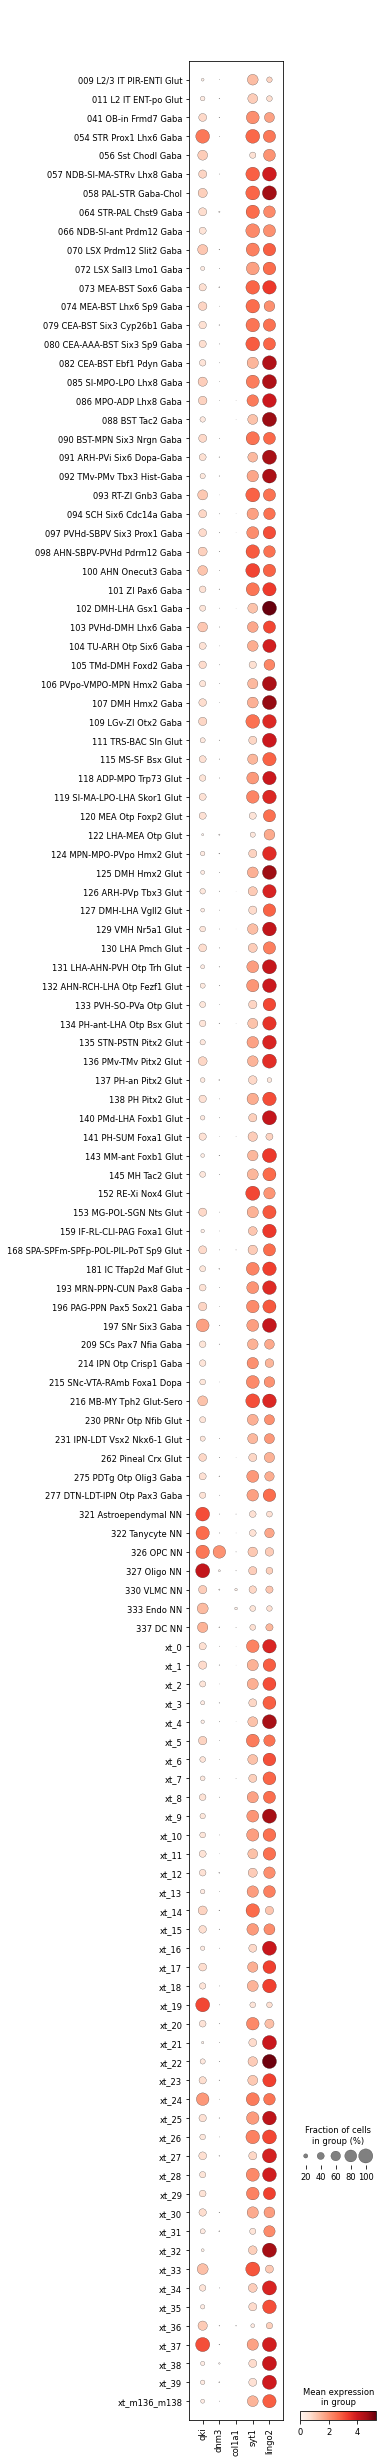

In [4]:
#look at gene expression
sc.pl.dotplot(sam.adata, var_names = ['qki','dnm3','col1a1','syt1','lingo2'], groupby=level)

In [ ]:
fin_vals = {}
for item in sam.adata.obs[level].unique():
    exp = np.average(sam.adata[sam.adata.obs[level] == item].X.A[:,gene_dict['SYT1']])
    fin_vals[item] = exp

In [ ]:
plt.hist(fin_vals.values())

In [59]:
df = pd.read_csv('../../OTO_star_nothreshold_6species_ohnlogs_expressionthresh_08022026.tsv',delimiter = '\t',index_col='MM')

In [ ]:
#Prarie Vole NON NEURON MARKERS
fin_NN = {i:[] for i in sam.adata.obs[level]}
for item in sam.adata.obs[level].unique():
    raw_exp = sam.adata[sam.adata.obs[level] == item].X.A
    exp = np.average(raw_exp[:,gene_dict['Syt1']])
    fin_NN[item].append(exp < 1)
    exp = np.average(raw_exp[:,gene_dict['Ptgds']])
    fin_NN[item].append(exp > .25)
    exp = np.average(raw_exp[:,gene_dict['Rbfox2']])
    fin_NN[item].append(exp < 1.25)
    
NN_CT = []
for item in fin_NN:
    if np.sum(fin_NN[item]) > 1:
        print(item)
        NN_CT.append(item)
    elif item[-2:] == 'NN':
        print('Missing ' + item)

In [46]:
#Japanese quail NON NEURON MARKERS
fin_NN = {i:[] for i in sam.adata.obs[level]}
for item in sam.adata.obs[level].unique():
    raw_exp = sam.adata[sam.adata.obs[level] == item].X.A
    exp = np.average(raw_exp[:,gene_dict['SYT1']])
    fin_NN[item].append(exp < 2)
    exp = np.average(raw_exp[:,gene_dict['RBFOX2']])
    fin_NN[item].append(exp < 1.25)
    exp = np.average(raw_exp[:,gene_dict['PTPRN2']])
    fin_NN[item].append(exp < 2)
    
NN_CT = []
for item in fin_NN:
    if np.sum(fin_NN[item]) > 1:
        print(item)
        NN_CT.append(item)
    elif item[-2:] == 'NN':
        print('Missing ' + item)

327 Oligo NN
326 OPC NN
cj_14
cj_0
334 Microglia NN
319 Astro-TE NN
322 Tanycyte NN
329 ABC NN
323 Ependymal NN
321 Astroependymal NN
cj_26
330 VLMC NN
325 CHOR NN
332 SMC NN
333 Endo NN


In [32]:
#Green Anole NON NEURON MARKER
fin_NN = {i:[] for i in sam.adata.obs[level]}
for item in sam.adata.obs[level].unique():
    raw_exp = sam.adata[sam.adata.obs[level] == item].X.A
    exp = np.average(raw_exp[:,gene_dict['syt1']])
    fin_NN[item].append(exp < 1)
    exp = np.average(raw_exp[:,gene_dict['rbfox2']])
    fin_NN[item].append(exp < .6)
    exp = np.average(raw_exp[:,gene_dict['nrxn1']])
    fin_NN[item].append(exp < 2)
    exp = np.average(raw_exp[:,gene_dict['celf4']])
    fin_NN[item].append(exp < 2)
    
NN_CT = []
for item in fin_NN:
    if np.sum(fin_NN[item]) > 2:
        print(item)
        NN_CT.append(item)
    elif item[-2:] == 'NN':
        print('Missing ' + item)

327 Oligo NN
322 Tanycyte NN
330 VLMC NN
334 Microglia NN
319 Astro-TE NN
329 ABC NN
ac_3
323 Ependymal NN
338 Lymphoid NN
326 OPC NN
ac_17
333 Endo NN
335 BAM NN
ac_22
ac_34


In [18]:
#Xenopus Tropicalis NON NEURON MARKER
fin_NN = {i:[] for i in sam.adata.obs[level]}
for item in sam.adata.obs[level].unique():
    raw_exp = sam.adata[sam.adata.obs[level] == item].X.A
    exp = np.average(raw_exp[:,gene_dict['qki']])
    fin_NN[item].append(exp > 2)
    exp = np.average(raw_exp[:,gene_dict['dnm3']])
    fin_NN[item].append(exp > 2)
    exp = np.average(raw_exp[:,gene_dict['col1a1']])
    fin_NN[item].append(exp > .1)
    exp = np.average(raw_exp[:,gene_dict['syt1']])
    fin_NN[item].append(exp < .75)
    exp = np.average(raw_exp[:,gene_dict['lingo2']])
    fin_NN[item].append(exp < 1.5)
    
NN_CT = []
for item in fin_NN:
    if np.sum(fin_NN[item]) > 1:
        print(item)
        NN_CT.append(item)
    elif item[-2:] == 'NN':
        print('Missing ' + item)

337 DC NN
322 Tanycyte NN
327 Oligo NN
xt_19
326 OPC NN
330 VLMC NN
321 Astroependymal NN
xt_36
333 Endo NN


In [4]:
#DR NON NEURON MARKER
fin_NN = {i:[] for i in sam.adata.obs[level]}
for item in sam.adata.obs[level].unique():
    raw_exp = sam.adata[sam.adata.obs[level] == item].X.A
    exp = np.average(raw_exp[:,gene_dict['syt1a']])
    fin_NN[item].append(exp < .5)
    exp = np.average(raw_exp[:,gene_dict['tmsb2']])
    fin_NN[item].append(exp < 1)
    
NN_CT = []
for item in fin_NN:
    if np.sum(fin_NN[item]) > 1:
        print(item)
        NN_CT.append(item)
    elif item[-2:] == 'NN':
        print('Missing ' + item)

320 Astro-OLF NN
dr_2
333 Endo NN
337 DC NN
326 OPC NN
330 VLMC NN
338 Lymphoid NN
dr_18
323 Ependymal NN
dr_20
327 Oligo NN
dr_15
dr_33
dr_25
dr_30
332 SMC NN
dr_28
dr_31
322 Tanycyte NN


In [47]:
NN_adata = sam.adata[~sam.adata.obs[level].isin(NN_CT)]

In [48]:
NN_adata

View of AnnData object with n_obs × n_vars = 55792 × 20032
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'n_genes', 'n_counts', 'key', 'hicat_merged', 'subclass_id_label_mapping', 'subclass_id_label_lc', 'leiden_clusters', 'subclass_id_label_mapping_nounlabeled', 'neurotransmitter', 'region_label', 'subclass_id_label_reduced_mapping', 'subclass_id_label_reduced_lc', 'subclass_id_label_reduced_mapping_nounlabeled', 'fraction_match', 'best_match', 'frac_match_test', 'leiden_removal', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.8', 'seurat_clusters', 'SCT_snn_res.5', 'eq_subclass', 'eq_subclass_lc', 'eq_subclass_frac', 'eq_subclass_nounlabeled', 'eq_subclass_nounlabeled_NN', 'eq_subclass_nounlabeled_nmm', 'ss_subclass', 'ss_subclass_nounlabeled', 'ss_class', 'ss_subclass_nounlabeled_astro', 'ss_subclass_v2', 'ss_subclass_v2_nounlabeled', 'ss_subclass_nounlabeled_nmm', 'ss_subclass_v3_nounlabeled', 'subclass_id_label_crossed', 'ss_subclass_nounlabeled_nmm_v2', 'subclass_id_label_cr

In [49]:
t1 = sc.read_h5ad('../../Testing_Raw_Dat_RNASEQ_Joined/CJ_dat_v5nounlabeled_neuron_geneexp_09062026.h5ad')

In [50]:
t1.X

<55792x20032 sparse matrix of type '<class 'numpy.float32'>'
	with 63989031 stored elements in Compressed Sparse Row format>

In [51]:
NN_adata.X

<55792x20032 sparse matrix of type '<class 'numpy.float32'>'
	with 63989031 stored elements in Compressed Sparse Row format>

In [22]:
#NN_adata.write_h5ad('../../DR_dat_v5nounlabeled_neuron_geneexp_09062026.h5ad')

In [52]:
nonneuron_adata = sam.adata[sam.adata.obs[level].isin(NN_CT)]

In [53]:
nonneuron_adata

View of AnnData object with n_obs × n_vars = 18966 × 20032
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'n_genes', 'n_counts', 'key', 'hicat_merged', 'subclass_id_label_mapping', 'subclass_id_label_lc', 'leiden_clusters', 'subclass_id_label_mapping_nounlabeled', 'neurotransmitter', 'region_label', 'subclass_id_label_reduced_mapping', 'subclass_id_label_reduced_lc', 'subclass_id_label_reduced_mapping_nounlabeled', 'fraction_match', 'best_match', 'frac_match_test', 'leiden_removal', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.8', 'seurat_clusters', 'SCT_snn_res.5', 'eq_subclass', 'eq_subclass_lc', 'eq_subclass_frac', 'eq_subclass_nounlabeled', 'eq_subclass_nounlabeled_NN', 'eq_subclass_nounlabeled_nmm', 'ss_subclass', 'ss_subclass_nounlabeled', 'ss_class', 'ss_subclass_nounlabeled_astro', 'ss_subclass_v2', 'ss_subclass_v2_nounlabeled', 'ss_subclass_nounlabeled_nmm', 'ss_subclass_v3_nounlabeled', 'subclass_id_label_crossed', 'ss_subclass_nounlabeled_nmm_v2', 'subclass_id_label_cr

In [54]:
nonneuron_adata.obs[level].value_counts()

327 Oligo NN             9155
cj_0                     4659
326 OPC NN               2292
322 Tanycyte NN           559
319 Astro-TE NN           466
330 VLMC NN               438
323 Ependymal NN          284
334 Microglia NN          265
cj_14                     260
321 Astroependymal NN     220
329 ABC NN                149
cj_26                     116
333 Endo NN                38
332 SMC NN                 37
325 CHOR NN                28
Name: ss_subclass_v5_nounlabeled, dtype: int64

In [55]:
t2 = sc.read_h5ad('../../Testing_Raw_Dat_RNASEQ_Joined/CJ_dat_v5nounlabeled_NONneuron_geneexp_09062026.h5ad')

In [56]:
t2.X

<18966x20032 sparse matrix of type '<class 'numpy.float32'>'
	with 22658175 stored elements in Compressed Sparse Row format>

In [57]:
nonneuron_adata.X

<18966x20032 sparse matrix of type '<class 'numpy.float32'>'
	with 22658175 stored elements in Compressed Sparse Row format>

In [26]:
#nonneuron_adata.write_h5ad('../../DR_dat_v5nounlabeled_NONneuron_geneexp_09062026.h5ad')